# Trust score on an L-shaped toy: realism + faithfulness

This notebook illustrates how the trust score's two components — **global realism** (Mahalanobis distance to the real feature distribution) and **attribute-wise faithfulness** (per-attribute margins against competing values) — combine to identify which regions of feature space are trustworthy for a *compositionally shifted* request.

**Setup.** Two binary attributes $(a_1, a_2)$, each $\in \{0, 1\}$. The training data has three seen conditions — $(0,0)$, $(0,1)$, $(1,0)$ — arranged so the union of their supports forms an **L shape** in the $(a_1, a_2)$ feature plane. The fourth condition $(1,1)$ is **unseen**.

**Question.** For a generated sample claiming target $(1,1)$, which region of feature space would the trust score accept?
- **Faithfulness** prefers the upper-right corner (both attributes high → matches the requested $(1,1)$).
- **Realism** prefers the L itself (low Mahalanobis distance to seen support).
- **Trust** accepts only the region where the two components *agree*.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from sklearn.covariance import LedoitWolf

rng = np.random.default_rng(0)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})


## 1. Synthesize the L-shaped data

Three isotropic Gaussian clusters, one per seen condition. Cluster centers are placed at the corners $(0,0)$, $(0,1)$, $(1,0)$ of the unit square — leaving $(1,1)$ empty.


In [2]:
# Cluster means: each row is (attr1, attr2)
means = {
    (0, 0): np.array([0.0, 0.0]),
    (0, 1): np.array([0.0, 1.0]),
    (1, 0): np.array([1.0, 0.0]),
}
sigma = 0.12  # tight clusters so the L is clearly visible
n_per = 400

X_by_cond = {
    cond: mu + sigma * rng.standard_normal(size=(n_per, 2))
    for cond, mu in means.items()
}
X = np.concatenate(list(X_by_cond.values()), axis=0)
y = np.concatenate([
    np.full(n_per, i, dtype=int) for i in range(len(means))
])  # cluster id 0,1,2 for (0,0), (0,1), (1,0)

TARGET = (1, 1)  # the unseen request


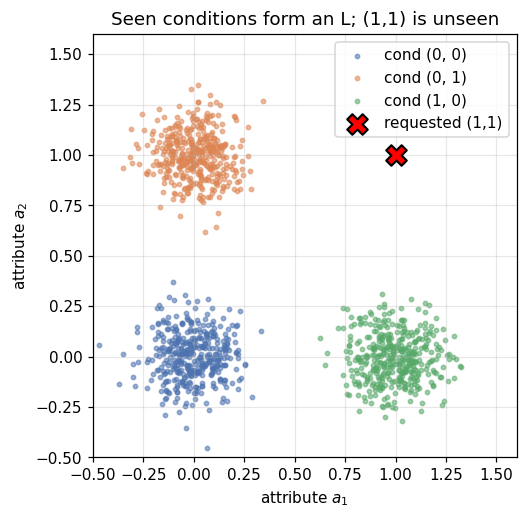

In [3]:
# Visualize the training data + mark the unseen target
fig, ax = plt.subplots(figsize=(5, 5))
colors = ['#4c72b0', '#dd8452', '#55a868']
for (cond, pts), c in zip(X_by_cond.items(), colors):
    ax.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.55, color=c,
               label=f'cond {cond}')
ax.scatter(*TARGET, marker='X', s=180, color='red', edgecolor='black',
           linewidth=1.4, zorder=5, label='requested (1,1)')
ax.set_xlabel(r'attribute $a_1$')
ax.set_ylabel(r'attribute $a_2$')
ax.set_xlim(-0.5, 1.6); ax.set_ylim(-0.5, 1.6)
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.legend(loc='upper right', frameon=True)
ax.set_title('Seen conditions form an L; (1,1) is unseen')
plt.show()


## 2. Realism: Mahalanobis distance to the pooled real distribution

Fit a single Gaussian (Ledoit–Wolf-shrunk covariance) to the pooled real features. Realism is the negative Mahalanobis distance (higher = more real). The contour tracks the L.


In [4]:
lw = LedoitWolf().fit(X)
mu_real = lw.location_
prec_real = lw.precision_

def mahalanobis_sq(points, mu, prec):
    d = points - mu
    return np.einsum('ni,ij,nj->n', d, prec, d)

# Grid for heatmaps
grid_n = 240
x_g = np.linspace(-0.6, 1.7, grid_n)
y_g = np.linspace(-0.6, 1.7, grid_n)
XX, YY = np.meshgrid(x_g, y_g)
grid_points = np.stack([XX.ravel(), YY.ravel()], axis=1)

M = mahalanobis_sq(grid_points, mu_real, prec_real).reshape(XX.shape)
realism = -M  # higher = more real


## 3. Faithfulness: per-attribute margins for target (1,1)

For each attribute $k$, build prototypes for $a_k = 0$ and $a_k = 1$ from the *seen* conditions:

- $a_1 = 0$ prototype: pooled cond $(0,0) \cup (0,1)$.
- $a_1 = 1$ prototype: cond $(1,0)$ — the only seen condition with $a_1 = 1$.
- $a_2 = 0$ prototype: pooled cond $(0,0) \cup (1,0)$.
- $a_2 = 1$ prototype: cond $(0,1)$.

Each prototype is a Gaussian with its own Mahalanobis distance. The **margin** for attribute $k$ with target $t_k$ is
$$M_k(x; t_k) = d_k(x; \text{NOT}\,t_k) - d_k(x; t_k),$$
so it is positive when $x$ is closer to the target value than to the alternative. Faithfulness for the joint target $(1,1)$ averages the two margins.


In [5]:
def fit_prototype(points):
    lw = LedoitWolf().fit(points)
    return lw.location_, lw.precision_

# Prototype features per attribute value
proto_a1 = {
    0: fit_prototype(np.concatenate([X_by_cond[(0, 0)], X_by_cond[(0, 1)]])),
    1: fit_prototype(X_by_cond[(1, 0)]),
}
proto_a2 = {
    0: fit_prototype(np.concatenate([X_by_cond[(0, 0)], X_by_cond[(1, 0)]])),
    1: fit_prototype(X_by_cond[(0, 1)]),
}

def margin(points, proto_t, proto_nt):
    """d(point ; not-target) - d(point ; target). Positive = faithful."""
    mu_t, P_t = proto_t
    mu_n, P_n = proto_nt
    return (mahalanobis_sq(points, mu_n, P_n)
            - mahalanobis_sq(points, mu_t, P_t))

m1 = margin(grid_points, proto_a1[1], proto_a1[0]).reshape(XX.shape)
m2 = margin(grid_points, proto_a2[1], proto_a2[0]).reshape(XX.shape)
faithfulness = 0.5 * (m1 + m2)


## 4. The two heatmaps side by side


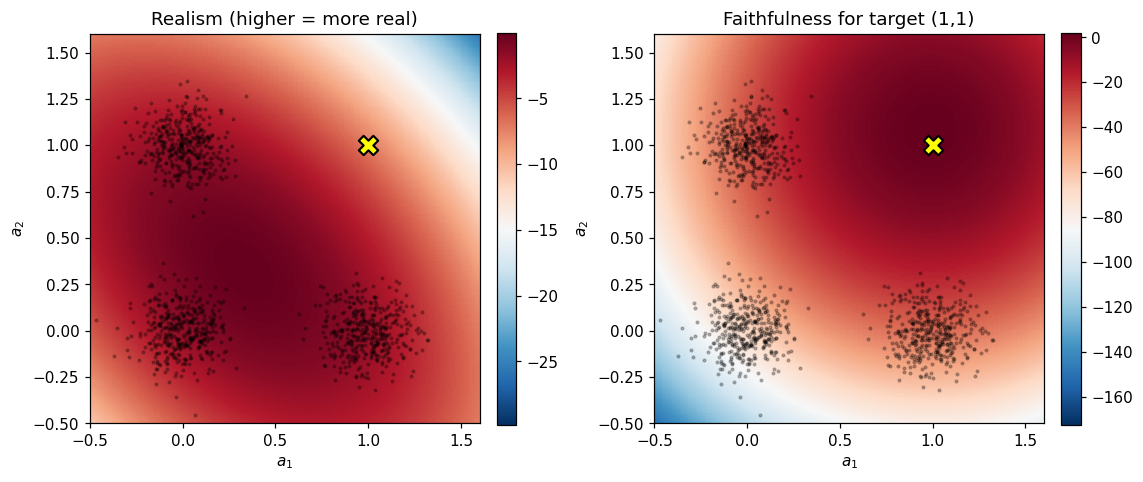

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8))

for ax, field, title in [
    (axes[0], realism, 'Realism (higher = more real)'),
    (axes[1], faithfulness, 'Faithfulness for target (1,1)'),
]:
    im = ax.pcolormesh(XX, YY, field, cmap='RdBu_r', shading='auto')
    ax.scatter(X[:, 0], X[:, 1], s=3, color='black', alpha=0.25)
    ax.scatter(*TARGET, marker='X', s=160, color='yellow',
               edgecolor='black', linewidth=1.4, zorder=5)
    ax.set_xlim(-0.5, 1.6); ax.set_ylim(-0.5, 1.6)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$a_1$'); ax.set_ylabel(r'$a_2$')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


**Read the heatmaps:**
- *Realism* is high along the L (the seen support) and falls off everywhere else, including at the requested $(1,1)$ corner.
- *Faithfulness* for target $(1,1)$ is highest in the upper-right quadrant — right where realism is lowest.

The two components **disagree** about $(1,1)$. The trust score is exactly the intersection of the two, so it will refuse to accept that corner.


## 5. Agreement region

Standardize both components to a comparable scale (z-score against their values on real samples), then identify the region where **both** are above their real-sample percentile — that is the trust-accepted region.


In [7]:
# Component values on the real samples — used to standardize and threshold
realism_real = -mahalanobis_sq(X, mu_real, prec_real)
m1_real = margin(X, proto_a1[1], proto_a1[0])
m2_real = margin(X, proto_a2[1], proto_a2[0])
faith_real = 0.5 * (m1_real + m2_real)

def zscore(field, ref):
    return (field - ref.mean()) / (ref.std() + 1e-9)

R_z = zscore(realism, realism_real)
F_z = zscore(faithfulness, faith_real)
trust = R_z + F_z

# Acceptance threshold: real-sample 5th percentile on each component
p_thresh = 5.0
R_thresh = np.percentile(zscore(realism_real, realism_real), p_thresh)
F_thresh = np.percentile(zscore(faith_real, faith_real), p_thresh)
accept = (R_z >= R_thresh) & (F_z >= F_thresh)


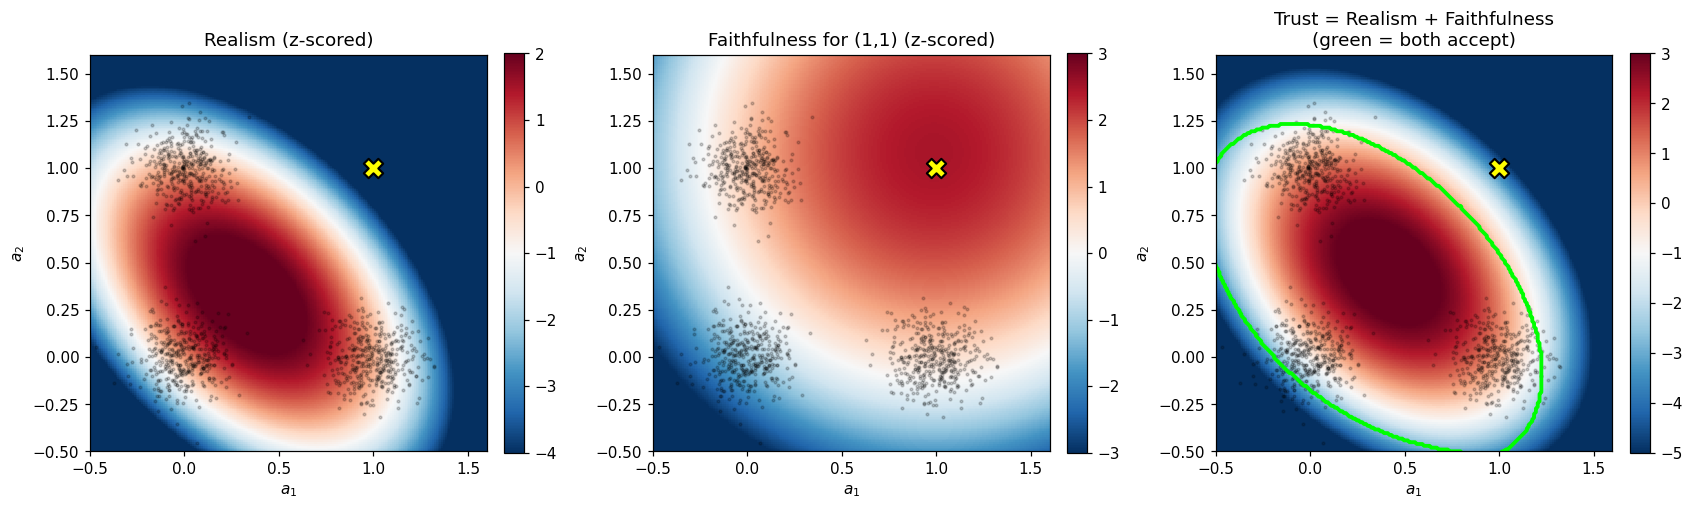

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8))

im0 = axes[0].pcolormesh(XX, YY, R_z, cmap='RdBu_r', shading='auto',
                          norm=Normalize(vmin=-4, vmax=2))
axes[0].set_title('Realism (z-scored)')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].pcolormesh(XX, YY, F_z, cmap='RdBu_r', shading='auto',
                          norm=Normalize(vmin=-3, vmax=3))
axes[1].set_title('Faithfulness for (1,1) (z-scored)')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Trust panel: show z-scored sum, then overlay the binary agreement mask
im2 = axes[2].pcolormesh(XX, YY, trust, cmap='RdBu_r', shading='auto',
                          norm=Normalize(vmin=-5, vmax=3))
axes[2].contour(XX, YY, accept.astype(float), levels=[0.5],
                colors='lime', linewidths=2.5)
axes[2].set_title('Trust = Realism + Faithfulness\n(green = both accept)')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.scatter(X[:, 0], X[:, 1], s=3, color='black', alpha=0.18)
    ax.scatter(*TARGET, marker='X', s=160, color='yellow',
               edgecolor='black', linewidth=1.4, zorder=5)
    ax.set_xlim(-0.5, 1.6); ax.set_ylim(-0.5, 1.6)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$a_1$'); ax.set_ylabel(r'$a_2$')
    ax.set_ylabel(r'$a_2$')
plt.tight_layout()
plt.show()


## 6. What the demo shows

The green contour in the third panel encloses the region where realism **and** faithfulness both clear their real-sample acceptance thresholds — the only place the trust score is willing to call a generated $(1,1)$ sample trustworthy.

On this L-shaped support the agreement region is **empty or near-empty around $(1,1)$**: faithfulness peaks where the data is absent. That is the correct behavior under compositional shift — the score abstains rather than rubber-stamp the request.

On real data the analogous picture is high-dimensional: realism uses the Mahalanobis precision of the pooled real features in DINOv3 / SigLIP space, faithfulness uses per-attribute margins against competing values, and the z-scoring and percentile threshold are computed on a held-out real split. The geometry is the same as in this notebook — see `src/faithful_cond_gen/eval/trust_eval/scoring_core.py` for the full implementation.
